In [1]:
import numpy as np
import matplotlib.pyplot as plt
import wimprates as wp
import numericalunits as nu

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(


norm1: 1.0032701307631677
norm2: 1.0000010826422643


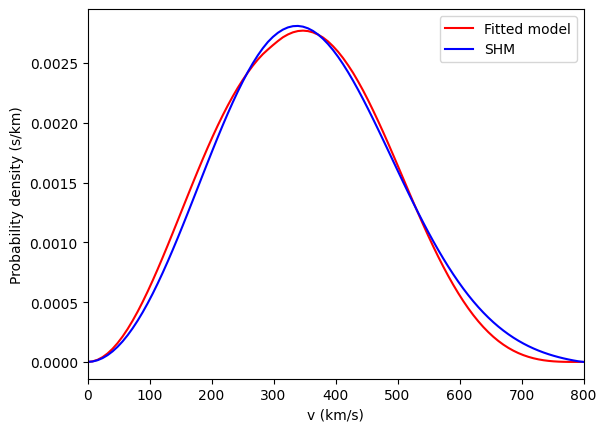

In [ ]:
#Define a pre computed distribution function of speed relative to Earth for both standard halo model and other model
#escape velocity from galaxy at sun in km/s for new model
vesc=542
halo_modelnew=wp.HaloModelInterpolatedFromFile(Filename="../wimprates/data/dataMW1/FourCoefs.txt",v_esc=vesc*nu.km/nu.s)
halo_modelS=wp.StandardHaloModel()
#speed in km/s
vels=np.linspace(0.01,800.,100)
dv=vels[1]-vels[0]
t1=67
#speed distribution function in s/km
DistFuncValst1=np.array(halo_modelnew.velocity_dist(vels*nu.km/nu.s,t=t1))*(nu.km/nu.s)
DistFuncValsSHMt1=np.array(halo_modelS.velocity_dist(vels*nu.km/nu.s,t=t1))*(nu.km/nu.s)
#Should integrate to one 
print("norm1:",np.sum(DistFuncValst1)*dv,)
print("norm2:",np.sum(DistFuncValsSHMt1)*dv)
plt.plot(vels,DistFuncValst1,label="Fitted model",color="red")
plt.plot(vels,DistFuncValsSHMt1,label="SHM",color="blue")
plt.legend()
plt.xlim(0,vels.max())
plt.xlabel("v (km/s)")
plt.ylabel("Probability density (s/km)")
plt.show()

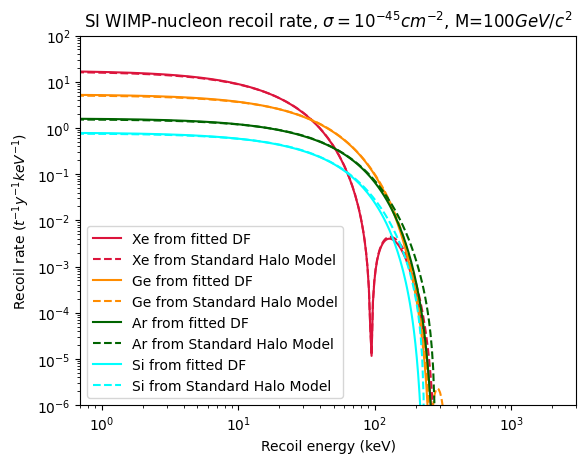

In [ ]:
#Now we plot the wimp rate recoil mass for the two models Note the density is set to be 0.3 Gev/c^2/cm^3
etrue_centers = np.geomspace(0.1,1000,400)
mw = 100
t=59.37
for color, target in zip(["crimson","darkorange","darkgreen","cyan"],["Xe","Ge","Ar","Si"]):
    r_new=wp.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_modelnew, material=target)
    r_old=wp.rate_wimp_std(etrue_centers,mw=mw,sigma_nucleon=1e-45, halo_model=halo_modelS, material=target)
    plt.plot(etrue_centers, r_new,color=color,linestyle="-", label=target+" from fitted DF")
    plt.plot(etrue_centers, r_old,color=color,linestyle="--", label=target+" from Standard Halo Model")
plt.yscale("log")
plt.xlim(0.7,3000)
plt.yscale("log")
plt.ylim(1e-6,100)
plt.xscale("log")
plt.legend()
plt.xlabel("Recoil energy (keV)")
plt.ylabel("Recoil rate ($t^{-1} y^{-1}keV^{-1}$)")
plt.title("SI WIMP-nucleon recoil rate, $\\sigma=10^{-45} cm^{-2}$, M=$"+str(mw)+"GeV/c^2$")
plt.show()